# 01 — Explore SambaGraph

This notebook is intended to be the first public-facing demo for the SambaGraph dataset. It shows how to:

- load the global episode and pair tables;
- inspect episode, split, label, and anchor distributions;
- load a full 23-node graph NPZ and the attack/defense 12-node views;
- visualize player–ball graph snapshots on a soccer pitch;
- inspect retrieved positive and hard-negative defense examples;

In [18]:
# === Imports ===
from __future__ import annotations

import json
import os
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Arc, Circle
from tqdm.auto import tqdm

from IPython.display import display, Markdown, Video, Image

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)

In [37]:
# === Configuration ===
CURATED_ROOT = Path(os.environ.get("SAMBAGRAPH_ROOT", "curated_dataset_wc22"))
GLOBAL_DIR = CURATED_ROOT / "_global"
OUT_DIR = GLOBAL_DIR / "exploration_outputs"
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Optional filters for selecting a demo episode.
SELECT_ATTACK_ID = None   # e.g., "10515_2_free_kick_6720187"
COARSE_FILTER = None      # e.g., "SUCCESS", "STOPPED_BY_DEFENSE", "FOUL_STOP", "UNKNOWN_OTHER"
ANCHOR_FILTER = None      # e.g., "corner", "shot", "free_kick"
SAMPLE_SEED = 7

#print("CURATED_ROOT:", CURATED_ROOT.resolve() if CURATED_ROOT.exists() else CURATED_ROOT)
print("GLOBAL_DIR:", GLOBAL_DIR)
print("OUT_DIR:", OUT_DIR)

GLOBAL_DIR: curated_dataset_wc22\_global
OUT_DIR: curated_dataset_wc22\_global\exploration_outputs


In [20]:
# === Helpers ===

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None


def resolve_path(p: Any, bases: Optional[List[Path]] = None) -> Optional[Path]:
    if p is None or (isinstance(p, float) and np.isnan(p)):
        return None
    s = str(p).strip()
    if s == "" or s.lower() in {"none", "nan", "null"}:
        return None
    path = Path(s)
    if path.is_absolute():
        return path
    bases = bases or [Path.cwd(), CURATED_ROOT, GLOBAL_DIR]
    for base in bases:
        cand = base / path
        if cand.exists():
            return cand
    return bases[0] / path


def map_to_coarse(label: Any) -> str:
    if label is None or (isinstance(label, float) and np.isnan(label)):
        return "UNKNOWN_OTHER"
    lab = str(label).upper().strip()
    if lab in {"GOAL", "PENALTY", "PENALTY_WON"}:
        return "SUCCESS"
    if lab.startswith("SHOT_"):
        return "STOPPED_BY_DEFENSE"
    if lab.startswith("FOUL"):
        return "FOUL_STOP"
    if lab.startswith("END_"):
        return "STOPPED_BY_DEFENSE"
    if lab in {"UNKNOWN", "OTHER", "UNK", "NA", "NAN"}:
        return "UNKNOWN_OTHER"
    return "UNKNOWN_OTHER"


def load_npz(path: Any):
    rp = resolve_path(path)
    if rp is None or not rp.exists():
        raise FileNotFoundError(f"NPZ file not found: {path}")
    return np.load(rp, allow_pickle=True), rp


def safe_value_counts(s: pd.Series) -> pd.DataFrame:
    return s.value_counts(dropna=False).rename_axis(s.name or "value").reset_index(name="count")

## 1. Load SambaGraph tables

In [21]:
MASTER_EP = first_existing([
    GLOBAL_DIR / "step2_5_outputs" / "master_episodes_with_coarse.parquet",
    GLOBAL_DIR / "master_episodes_with_coarse.parquet",
    GLOBAL_DIR / "master_episodes.parquet",
    CURATED_ROOT / "master_episodes.parquet",
])
MASTER_PAIRS = first_existing([
    GLOBAL_DIR / "step2_5_outputs" / "formal_pairs.parquet",
    GLOBAL_DIR / "master_pairs.parquet",
    GLOBAL_DIR / "training_pairs.parquet",
    CURATED_ROOT / "training_pairs.parquet",
])

print("MASTER_EP:", MASTER_EP)
print("MASTER_PAIRS:", MASTER_PAIRS)

if MASTER_EP is None:
    raise FileNotFoundError("Could not find master episodes table. Edit CURATED_ROOT.")

episodes = pd.read_parquet(MASTER_EP)
if "coarse_label" not in episodes.columns:
    episodes = episodes.copy()
    episodes["coarse_label"] = episodes["response_label"].apply(map_to_coarse)

pairs = pd.read_parquet(MASTER_PAIRS) if MASTER_PAIRS is not None else None

print("episodes:", episodes.shape)
print("pairs:", None if pairs is None else pairs.shape)
display(episodes.head(3))
if pairs is not None:
    display(pairs.head(3))

MASTER_EP: curated_dataset_wc22\_global\step2_5_outputs\master_episodes_with_coarse.parquet
MASTER_PAIRS: curated_dataset_wc22\_global\step2_5_outputs\formal_pairs.parquet
episodes: (4070, 31)
pairs: (26270, 4)


,attack_id,game_id,period,anchor_type,gameEventId,possessionEventId,t_response,response_label,success_score,is_success,is_failure,window_t0,window_t1,attack_end_idx,def_start_idx,def_end_idx,attacker_team,flip_x,game_dir,npz_full,npz_attack,npz_defense,combined_media,attack_media,defense_media,media_ext,events_flat_path,tgn_edges_path,training_pairs_path,split,coarse_label
0,10502_1_shot_6629878,10502,1,shot,6629878,6511176.0,309.710,SHOT_S,0.35,False,False,303.737070,321.688355,179,105,283,1,True,curated_dataset_wc22\game_10502,curated_dataset_wc22\game_10502\attack_windows_npz\10502_1_shot_6629878.npz,curated_dataset_wc22\game_10502\attack_view_npz\10502_1_shot_6629878_ATT.npz,curated_dataset_wc22\game_10502\defense_view_npz\10502_1_shot_6629878_DEF.npz,curated_dataset_wc22\game_10502\videos\combined\10502_1_shot_6629878.mp4,curated_dataset_wc22\game_10502\videos\attack\10502_1_shot_6629878_ATT.mp4,curated_dataset_wc22\game_10502\videos\defense\10502_1_shot_6629878_DEF.mp4,mp4,curated_dataset_wc22\game_10502\events_flat.parquet,None,curated_dataset_wc22\game_10502\training_pairs.parquet,train,STOPPED_BY_DEFENSE
1,10502_1_corner_6630328,10502,1,corner,6630328,6511620.0,593.427,UNKNOWN,0.00,False,False,581.948615,599.899900,344,270,448,1,True,curated_dataset_wc22\game_10502,curated_dataset_wc22\game_10502\attack_windows_npz\10502_1_corner_6630328.npz,curated_dataset_wc22\game_10502\attack_view_npz\10502_1_corner_6630328_ATT.npz,curated_dataset_wc22\game_10502\defense_view_npz\10502_1_corner_6630328_DEF.npz,curated_dataset_wc22\game_10502\videos\combined\10502_1_corner_6630328.mp4,curated_dataset_wc22\game_10502\videos\attack\10502_1_corner_6630328_ATT.mp4,curated_dataset_wc22\game_10502\videos\defense\10502_1_corner_6630328_DEF.mp4,mp4,curated_dataset_wc22\game_10502\events_flat.parquet,None,curated_dataset_wc22\game_10502\training_pairs.parquet,train,UNKNOWN
2,10502_1_goal_6630642,10502,1,goal,6630642,6511957.0,750.250,GOAL,1.00,True,False,744.277611,762.228896,178,105,283,0,False,curated_dataset_wc22\game_10502,curated_dataset_wc22\game_10502\attack_windows_npz\10502_1_goal_6630642.npz,curated_dataset_wc22\game_10502\attack_view_npz\10502_1_goal_6630642_ATT.npz,curated_dataset_wc22\game_10502\defense_view_npz\10502_1_goal_6630642_DEF.npz,curated_dataset_wc22\game_10502\videos\combined\10502_1_goal_6630642.mp4,curated_dataset_wc22\game_10502\videos\attack\10502_1_goal_6630642_ATT.mp4,curated_dataset_wc22\game_10502\videos\defense\10502_1_goal_6630642_DEF.mp4,mp4,curated_dataset_wc22\game_10502\events_flat.parquet,None,curated_dataset_wc22\game_10502\training_pairs.parquet,train,SUCCESS


,attack_id,defense_id,pair_type,weight
0,10502_1_shot_6629878,10502_1_shot_6629878,pos_same,1.000000
1,10502_1_shot_6629878,10502_2_corner_6629602,pos_retrieved_success,0.907041
2,10502_1_shot_6629878,10502_2_goal_6629644,pos_retrieved_success,0.863487


## 2. Dataset overview

In [22]:
overview = pd.DataFrame([{
    "episodes_total": len(episodes),
    "matches_total": episodes["game_id"].nunique() if "game_id" in episodes.columns else None,
    "train_episodes": int((episodes["split"] == "train").sum()) if "split" in episodes.columns else None,
    "val_episodes": int((episodes["split"] == "val").sum()) if "split" in episodes.columns else None,
    "test_episodes": int((episodes["split"] == "test").sum()) if "split" in episodes.columns else None,
    "unique_fine_labels": episodes["response_label"].nunique() if "response_label" in episodes.columns else None,
    "unique_coarse_labels": episodes["coarse_label"].nunique() if "coarse_label" in episodes.columns else None,
    "pairs_total": len(pairs) if pairs is not None else None,
}])

display(overview)
overview.to_csv(TABLE_DIR / "dataset_overview.csv", index=False)

if "split" in episodes.columns:
    split_counts = safe_value_counts(episodes["split"])
    display(split_counts)
    split_counts.to_csv(TABLE_DIR / "split_counts.csv", index=False)

coarse_counts = safe_value_counts(episodes["coarse_label"])
display(coarse_counts)
coarse_counts.to_csv(TABLE_DIR / "coarse_label_counts.csv", index=False)

if "anchor_type" in episodes.columns:
    anchor_counts = safe_value_counts(episodes["anchor_type"])
    display(anchor_counts)
    anchor_counts.to_csv(TABLE_DIR / "anchor_counts.csv", index=False)

,episodes_total,matches_total,train_episodes,val_episodes,test_episodes,unique_fine_labels,unique_coarse_labels,pairs_total
0,4070,64,3294,330,446,24,4,26270


,split,count
0,train,3294
1,test,446
2,val,330


,coarse_label,count
0,STOPPED_BY_DEFENSE,2201
1,FOUL_STOP,1066
2,UNKNOWN,464
3,SUCCESS,339


,anchor_type,count
0,free_kick,1792
1,foul_explicit,897
2,shot,670
3,corner,565
4,goal,122
5,penalty,24


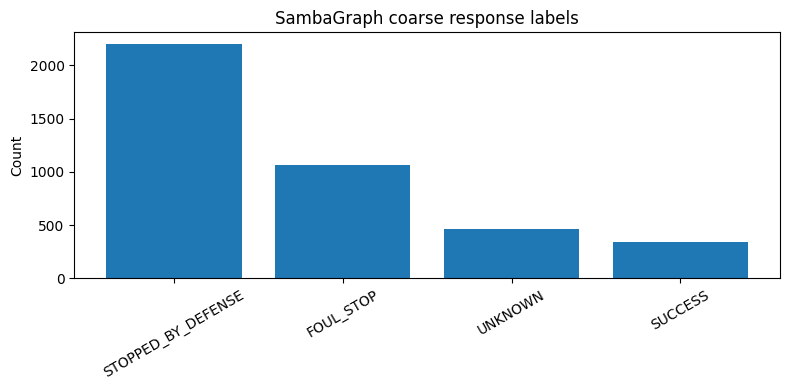

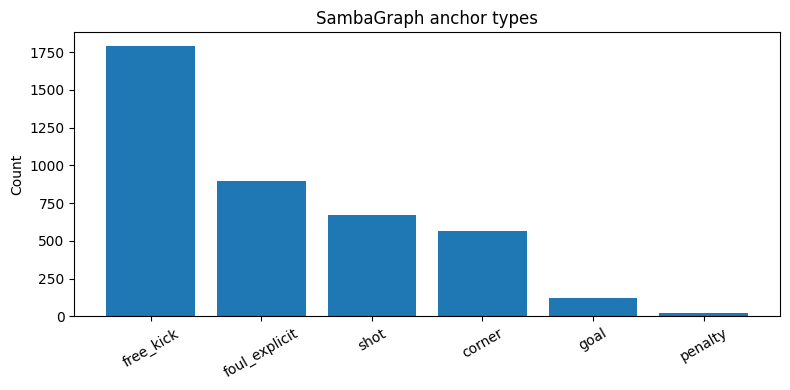

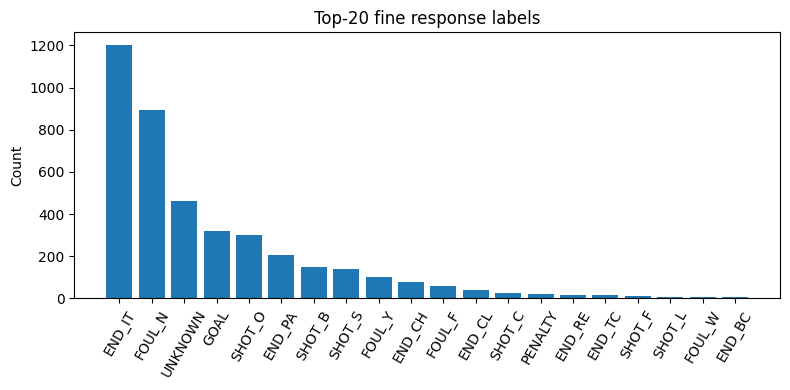

In [23]:
# Plot coarse-label and anchor distributions.

def bar_plot_counts(df: pd.DataFrame, x_col: str, y_col: str, title: str, out_path: Path, rotation: int = 30):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(df[x_col].astype(str), df[y_col].values)
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=rotation)
    fig.tight_layout()
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

bar_plot_counts(coarse_counts, "coarse_label", "count", "SambaGraph coarse response labels", FIG_DIR / "coarse_label_distribution.png")
if "anchor_type" in episodes.columns:
    bar_plot_counts(anchor_counts, "anchor_type", "count", "SambaGraph anchor types", FIG_DIR / "anchor_type_distribution.png")

if "response_label" in episodes.columns:
    fine_top = safe_value_counts(episodes["response_label"].astype(str)).head(20)
    bar_plot_counts(fine_top, "response_label", "count", "Top-20 fine response labels", FIG_DIR / "fine_label_top20.png", rotation=60)

## 3. Match-level distribution

,game_id,n_episodes,n_anchor_types,n_fine_labels
63,10517,110,6,11
39,3851,101,5,12
4,3816,83,6,13
52,10506,82,5,10
54,10508,79,4,12
20,3832,79,5,14
9,3821,78,6,11
21,3833,77,6,12
32,3844,77,6,14
46,3858,77,5,12


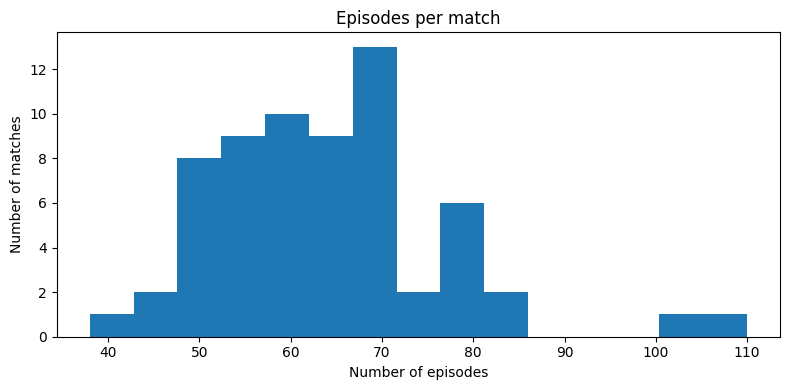

In [24]:
if "game_id" in episodes.columns:
    per_game = episodes.groupby("game_id").agg(
        n_episodes=("game_id", "count"),
        n_anchor_types=("anchor_type", "nunique") if "anchor_type" in episodes.columns else ("game_id", "count"),
        n_fine_labels=("response_label", "nunique") if "response_label" in episodes.columns else ("game_id", "count"),
    ).reset_index().sort_values("n_episodes", ascending=False)
    display(per_game.head(10))
    per_game.to_csv(TABLE_DIR / "per_game_episode_summary.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(per_game["n_episodes"], bins=15)
    ax.set_title("Episodes per match")
    ax.set_xlabel("Number of episodes")
    ax.set_ylabel("Number of matches")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "episodes_per_match_histogram.png", dpi=200, bbox_inches="tight")
    plt.show()

## 4. Select a representative episode

You can set `SELECT_ATTACK_ID`, `COARSE_FILTER`, or `ANCHOR_FILTER` in the configuration cell above. Otherwise, the notebook samples a valid episode that has a full NPZ file.

In [25]:
def has_existing_path(row: pd.Series, col: str) -> bool:
    if col not in row.index:
        return False
    p = resolve_path(row[col])
    return bool(p and p.exists())

cand = episodes.copy()
if SELECT_ATTACK_ID is not None:
    cand = cand[cand["attack_id"].astype(str) == str(SELECT_ATTACK_ID)]
if COARSE_FILTER is not None:
    cand = cand[cand["coarse_label"].astype(str) == str(COARSE_FILTER)]
if ANCHOR_FILTER is not None and "anchor_type" in cand.columns:
    cand = cand[cand["anchor_type"].astype(str) == str(ANCHOR_FILTER)]

if "npz_full" in cand.columns:
    exists_mask = cand["npz_full"].apply(lambda p: bool(resolve_path(p) and resolve_path(p).exists()))
    cand = cand[exists_mask]

if cand.empty:
    raise RuntimeError("No episode matched the selection filters and available NPZ files.")

sample_row = cand.sample(1, random_state=SAMPLE_SEED).iloc[0]
print("Selected attack_id:", sample_row.get("attack_id"))
print("game_id:", sample_row.get("game_id"), "split:", sample_row.get("split"))
print("anchor:", sample_row.get("anchor_type"), "fine label:", sample_row.get("response_label"), "coarse:", sample_row.get("coarse_label"))

display(sample_row.to_frame("value"))

Selected attack_id: 3813_1_corner_6496879
game_id: 3813 split: train
anchor: corner fine label: GOAL coarse: SUCCESS


,value
attack_id,3813_1_corner_6496879
game_id,3813
period,1
anchor_type,corner
gameEventId,6496879
possessionEventId,6373154.0
t_response,2746.446
response_label,GOAL
success_score,1.0
is_success,True


## 5. Load NPZ tensors

In [36]:
npz_full, full_path = load_npz(sample_row["npz_full"])
print("Full NPZ:")#, full_path)
print("Keys:", list(npz_full.keys()))

Xseq = npz_full["Xseq"]
times = npz_full["times"] if "times" in npz_full.files else np.arange(Xseq.shape[0])
print("Xseq shape:", Xseq.shape, "times shape:", times.shape)

# Optional team views
views = {}
for view_name, col in [("attack", "npz_attack"), ("defense", "npz_defense")]:
    if col in sample_row.index and pd.notna(sample_row[col]):
        try:
            z, p = load_npz(sample_row[col])
            views[view_name] = {"npz": z, "path": p, "Xseq": z["Xseq"] if "Xseq" in z.files else None}
            #print(f"{view_name} view:", p, "shape:", None if views[view_name]["Xseq"] is None else views[view_name]["Xseq"].shape)
            print(f"{view_name} view:", "shape:", None if views[view_name]["Xseq"] is None else views[view_name]["Xseq"].shape)

        except Exception as e:
            print(f"Could not load {view_name} view:", e)

Full NPZ:
Keys: ['node_uid', 'times', 'Xseq', 'edges_intra', 'edges_cross', 'edges_ball', 'f_src', 'f_dst', 'f_src_uid', 'f_dst_uid', 'f_ts', 'f_etype', 'f_tidx', 'response_label', 'attacker_team', 'flip_x']
Xseq shape: (554, 23, 5) times shape: (554,)
attack view: shape: (554, 12, 5)
defense view: shape: (554, 12, 5)


In [27]:
# Summarize tensor fields and flattened stream availability.
npz_summary = []
for key in npz_full.files:
    arr = npz_full[key]
    npz_summary.append({
        "key": key,
        "shape": str(arr.shape),
        "dtype": str(arr.dtype),
        "is_object": arr.dtype == object,
    })
npz_summary_df = pd.DataFrame(npz_summary)
display(npz_summary_df)
npz_summary_df.to_csv(TABLE_DIR / "selected_npz_fields.csv", index=False)

,key,shape,dtype,is_object
0,node_uid,"(23,)",int64,False
1,times,"(554,)",float64,False
2,Xseq,"(554, 23, 5)",float32,False
3,edges_intra,"(554,)",object,True
4,edges_cross,"(554,)",object,True
5,edges_ball,"(554,)",object,True
6,f_src,"(52302,)",int64,False
7,f_dst,"(52302,)",int64,False
8,f_src_uid,"(52302,)",int64,False
9,f_dst_uid,"(52302,)",int64,False


## 6. Plot graph snapshots on the pitch

The full graph uses 23 nodes: 11 home players, 11 away players, and the ball. Attack/defense views use 12 nodes each.

Using pff_viz.draw_pitch


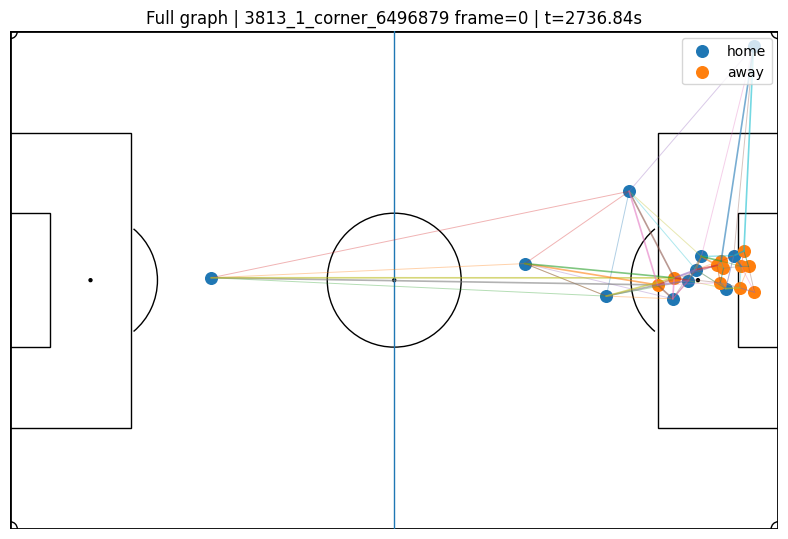

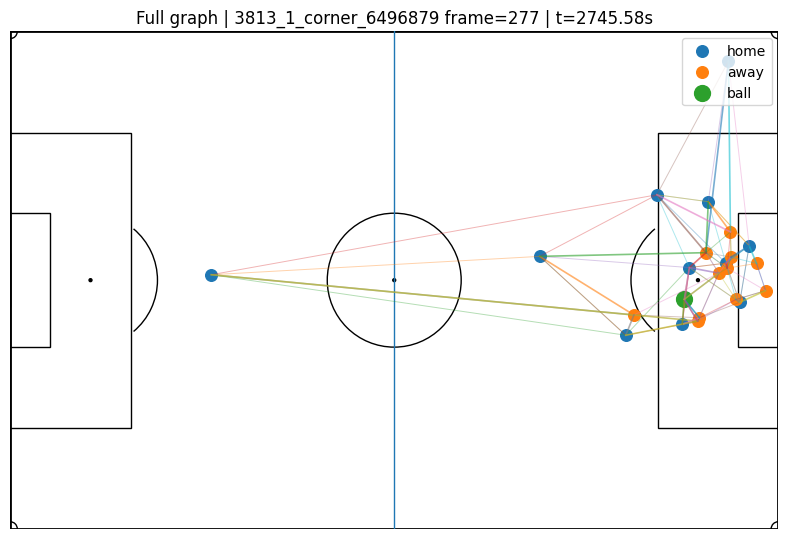

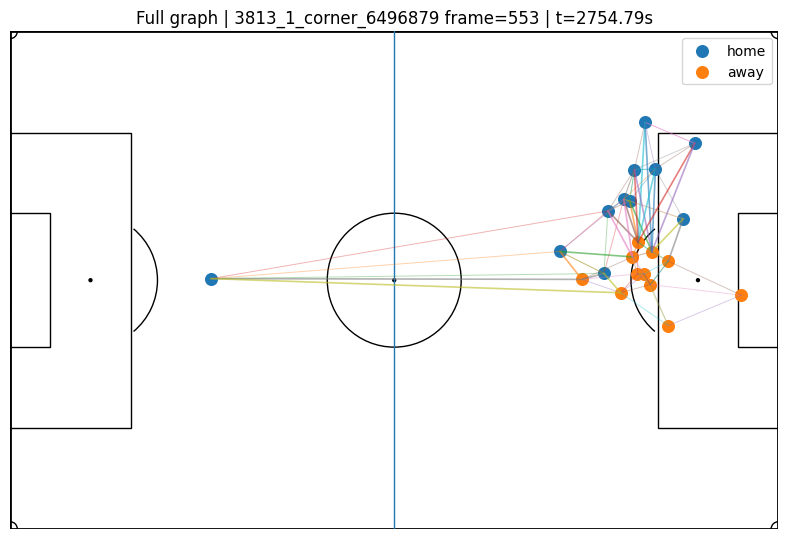

In [28]:
# Pitch drawing helper. Prefer local pff_viz.py if available, otherwise use fallback.
try:
    from pff_viz import draw_pitch
    print("Using pff_viz.draw_pitch")
except Exception:
    PITCH_L = 105.0
    PITCH_W = 68.0
    def draw_pitch(ax, line_width=1.5):
        ax.set_aspect("equal")
        ax.set_xlim(-PITCH_L/2, PITCH_L/2)
        ax.set_ylim(-PITCH_W/2, PITCH_W/2)
        ax.axis("off")
        ax.add_patch(Rectangle((-PITCH_L/2, -PITCH_W/2), PITCH_L, PITCH_W, fill=False, linewidth=line_width))
        ax.plot([0, 0], [-PITCH_W/2, PITCH_W/2], linewidth=1)
        ax.add_patch(Circle((0, 0), 9.15, fill=False, linewidth=1))
        ax.add_patch(Circle((0, 0), 0.2))
        pen_depth, pen_width = 16.5, 40.32
        six_depth, six_width = 5.5, 18.32
        ax.add_patch(Rectangle((-PITCH_L/2, -pen_width/2), pen_depth, pen_width, fill=False, linewidth=1))
        ax.add_patch(Rectangle((PITCH_L/2-pen_depth, -pen_width/2), pen_depth, pen_width, fill=False, linewidth=1))
        ax.add_patch(Rectangle((-PITCH_L/2, -six_width/2), six_depth, six_width, fill=False, linewidth=1))
        ax.add_patch(Rectangle((PITCH_L/2-six_depth, -six_width/2), six_depth, six_width, fill=False, linewidth=1))


def get_edges_at(z, key: str, t: int):
    if key not in z.files:
        return None
    arr = z[key]
    try:
        return arr[t]
    except Exception:
        return None


def plot_frame(z, t_idx: int, title: str = "", out_path: Optional[Path] = None):
    X = z["Xseq"][t_idx]
    xy = X[:, :2]
    valid = np.isfinite(xy).all(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5.5))
    draw_pitch(ax)

    if X.shape[0] >= 23:
        home = [i for i in range(11) if valid[i]]
        away = [i for i in range(11, 22) if valid[i]]
        ball = [22] if valid[22] else []
        ax.scatter(xy[home, 0], xy[home, 1], s=70, label="home")
        ax.scatter(xy[away, 0], xy[away, 1], s=70, label="away")
        if ball:
            ax.scatter([xy[22, 0]], [xy[22, 1]], s=130, label="ball")
    else:
        players = [i for i in range(min(11, X.shape[0])) if valid[i]]
        ball_idx = X.shape[0] - 1
        ax.scatter(xy[players, 0], xy[players, 1], s=70, label="players")
        if valid[ball_idx]:
            ax.scatter([xy[ball_idx, 0]], [xy[ball_idx, 1]], s=130, label="ball")

    for edge_key, lw, alpha in [("edges_intra", 0.7, 0.35), ("edges_cross", 1.2, 0.6), ("edges_ball", 1.1, 0.5)]:
        eidx = get_edges_at(z, edge_key, t_idx)
        if eidx is None:
            continue
        eidx = np.asarray(eidx)
        if eidx.ndim != 2 or eidx.shape[0] != 2:
            continue
        for k in range(eidx.shape[1]):
            u, v = int(eidx[0, k]), int(eidx[1, k])
            if u < len(valid) and v < len(valid) and valid[u] and valid[v]:
                ax.plot([xy[u, 0], xy[v, 0]], [xy[u, 1], xy[v, 1]], linewidth=lw, alpha=alpha)

    time_txt = ""
    if "times" in z.files:
        time_txt = f" | t={float(z['times'][t_idx]):.2f}s"
    ax.set_title(f"{title} frame={t_idx}{time_txt}")
    ax.legend(loc="upper right")
    fig.tight_layout()
    if out_path is not None:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    return fig

T = Xseq.shape[0]
frame_ids = sorted(set([0, T // 2, T - 1]))
for t in frame_ids:
    plot_frame(npz_full, t, title=f"Full graph | {sample_row.get('attack_id')}", out_path=FIG_DIR / f"selected_full_frame_{t}.png")

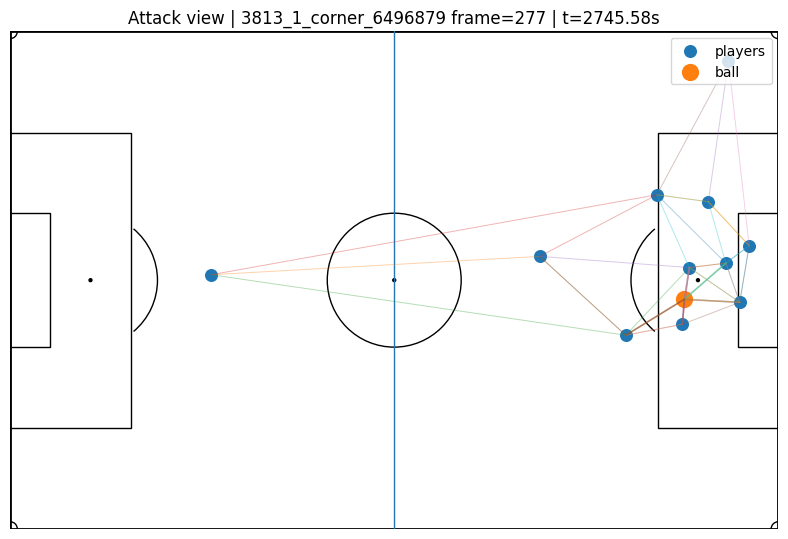

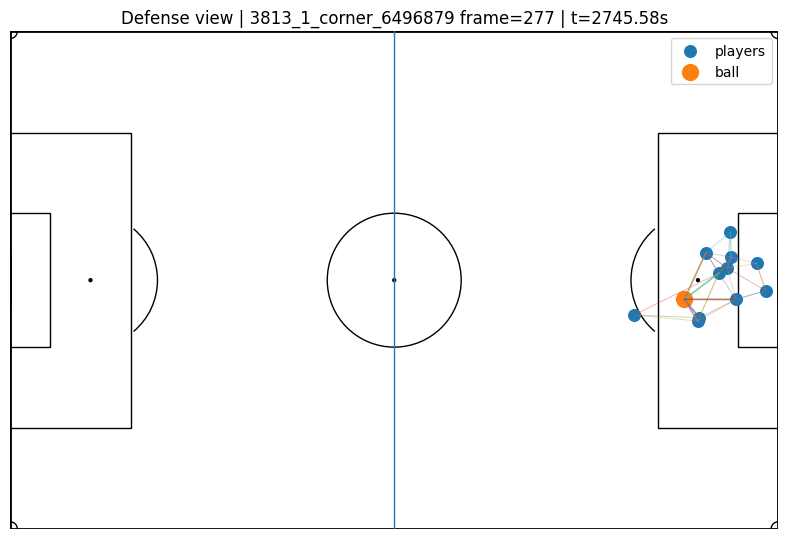

In [29]:
# Attack and defense view snapshots, if available.
for view_name, obj in views.items():
    z = obj["npz"]
    if "Xseq" not in z.files:
        continue
    T_view = z["Xseq"].shape[0]
    t = T_view // 2
    plot_frame(z, t, title=f"{view_name.capitalize()} view | {sample_row.get('attack_id')}", out_path=FIG_DIR / f"selected_{view_name}_view_mid.png")

## 7. Episode statistics from the tensor

These simple statistics are useful for sanity checks, retrieval baselines, and README examples.

In [30]:
def episode_tensor_stats(Xseq: np.ndarray) -> Dict[str, float]:
    xy = Xseq[..., :2]
    T, N, _ = xy.shape
    ball_idx = N - 1
    ball = xy[:, ball_idx, :]
    ball_valid = np.isfinite(ball).all(axis=1)

    stats = {
        "T": int(T),
        "N": int(N),
        "F": int(Xseq.shape[-1]),
        "ball_valid_pct": float(100.0 * ball_valid.mean()),
    }

    if ball_valid.any():
        b = ball[ball_valid]
        stats.update({
            "ball_x_start": float(b[0, 0]),
            "ball_y_start": float(b[0, 1]),
            "ball_x_end": float(b[-1, 0]),
            "ball_y_end": float(b[-1, 1]),
            "ball_dx": float(b[-1, 0] - b[0, 0]),
            "ball_dy": float(b[-1, 1] - b[0, 1]),
            "ball_path_length": float(np.linalg.norm(np.diff(b, axis=0), axis=1).sum()) if len(b) > 1 else 0.0,
        })

    # Team centroid/width/depth for full 23-node graph.
    if N >= 23:
        for name, sl in [("home", slice(0, 11)), ("away", slice(11, 22))]:
            pts = xy[:, sl, :]
            valid = np.isfinite(pts).all(axis=2)
            centroids = []
            widths = []
            depths = []
            for t in range(T):
                p = pts[t][valid[t]]
                if len(p) == 0:
                    continue
                centroids.append(p.mean(axis=0))
                widths.append(p[:, 1].max() - p[:, 1].min())
                depths.append(p[:, 0].max() - p[:, 0].min())
            if centroids:
                c = np.vstack(centroids)
                stats[f"{name}_centroid_x_mean"] = float(c[:, 0].mean())
                stats[f"{name}_centroid_y_mean"] = float(c[:, 1].mean())
                stats[f"{name}_width_mean"] = float(np.mean(widths))
                stats[f"{name}_depth_mean"] = float(np.mean(depths))
    return stats

stats = episode_tensor_stats(Xseq)
stats_df = pd.DataFrame([stats])
display(stats_df.T.rename(columns={0: "value"}))
stats_df.to_csv(TABLE_DIR / "selected_episode_tensor_stats.csv", index=False)

,value
T,554.000000
N,23.000000
F,5.000000
ball_valid_pct,64.079422
ball_x_start,48.150002
ball_y_start,40.500000
ball_x_end,47.740002
ball_y_end,-3.380000
ball_dx,-0.410000
ball_dy,-43.880001


## 8. Media preview

If the dataset includes rendered GIF/MP4 files, this cell previews the selected episode.

In [35]:
media_cols = [c for c in ["combined_media", "attack_media", "defense_media"] if c in sample_row.index]
for col in media_cols:
    p = resolve_path(sample_row[col])
    if p is None or not p.exists():
        continue
    print(col, ":")#, p)
    suffix = p.suffix.lower()
    if suffix in {".mp4", ".mov", ".m4v", ".webm"}:
        display(Video(str(p), embed=True, width=720))
    elif suffix in {".gif", ".png", ".jpg", ".jpeg"}:
        display(Image(filename=str(p), width=720))

combined_media :


attack_media :


defense_media :


## 9. Inspect attack-to-defense pairs

This section shows retrieved positive and hard-negative defense examples for the selected attacking episode.

In [32]:
if pairs is None:
    print("No pair table available.")
else:
    ep_lookup = episodes.set_index(episodes["attack_id"].astype(str))
    p = pairs.copy()
    p["attack_id"] = p["attack_id"].astype(str)
    p["defense_id"] = p["defense_id"].astype(str)
    selected_pairs = p[p["attack_id"] == str(sample_row["attack_id"])].copy()

    if selected_pairs.empty:
        print("No pairs found for selected episode.")
    else:
        selected_pairs["def_response_label"] = selected_pairs["defense_id"].map(ep_lookup["response_label"].astype(str).to_dict())
        selected_pairs["def_coarse_label"] = selected_pairs["defense_id"].map(ep_lookup["coarse_label"].astype(str).to_dict())
        if "anchor_type" in ep_lookup.columns:
            selected_pairs["def_anchor_type"] = selected_pairs["defense_id"].map(ep_lookup["anchor_type"].astype(str).to_dict())
        if "game_id" in ep_lookup.columns:
            selected_pairs["def_game_id"] = selected_pairs["defense_id"].map(ep_lookup["game_id"].to_dict())
        display(selected_pairs.sort_values(["pair_type", "weight"], ascending=[True, False]).head(20))

        selected_pairs.to_csv(TABLE_DIR / "selected_episode_pairs.csv", index=False)

        # Defense-side label audit for the whole pair table.
        p["def_coarse_label"] = p["defense_id"].map(ep_lookup["coarse_label"].astype(str).to_dict())
        pair_audit = pd.crosstab(p["pair_type"], p["def_coarse_label"])
        display(pair_audit)
        pair_audit.to_csv(TABLE_DIR / "pair_defense_label_audit.csv")

,attack_id,defense_id,pair_type,weight,def_response_label,def_coarse_label,def_anchor_type,def_game_id
7110,3813_1_corner_6496879,3813_2_corner_6496617,neg_hard_failure,0.990255,END_IT,STOPPED_BY_DEFENSE,corner,3813
7111,3813_1_corner_6496879,3813_1_free_kick_6497010,neg_hard_failure,0.935100,END_IT,STOPPED_BY_DEFENSE,free_kick,3813
7112,3813_1_corner_6496879,3813_1_free_kick_6496729,neg_hard_failure,0.930244,END_IT,STOPPED_BY_DEFENSE,free_kick,3813
7107,3813_1_corner_6496879,3813_1_goal_6496889,pos_retrieved_success,0.999713,GOAL,SUCCESS,goal,3813
7108,3813_1_corner_6496879,3813_1_shot_6496889,pos_retrieved_success,0.999713,GOAL,SUCCESS,shot,3813
7109,3813_1_corner_6496879,3813_1_goal_6496219,pos_retrieved_success,0.982550,GOAL,SUCCESS,goal,3813
7106,3813_1_corner_6496879,3813_1_corner_6496879,pos_same,1.000000,GOAL,SUCCESS,corner,3813


def_coarse_label,FOUL_STOP,STOPPED_BY_DEFENSE,SUCCESS,UNKNOWN
pair_type,,,,
neg_hard_failure,0,12210,0,0
pos_retrieved_success,0,0,9990,0
pos_same,1066,2201,339,464


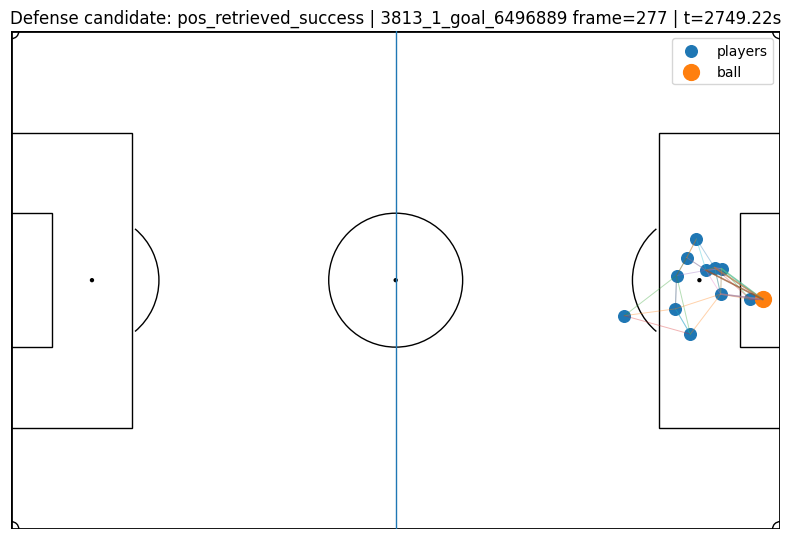

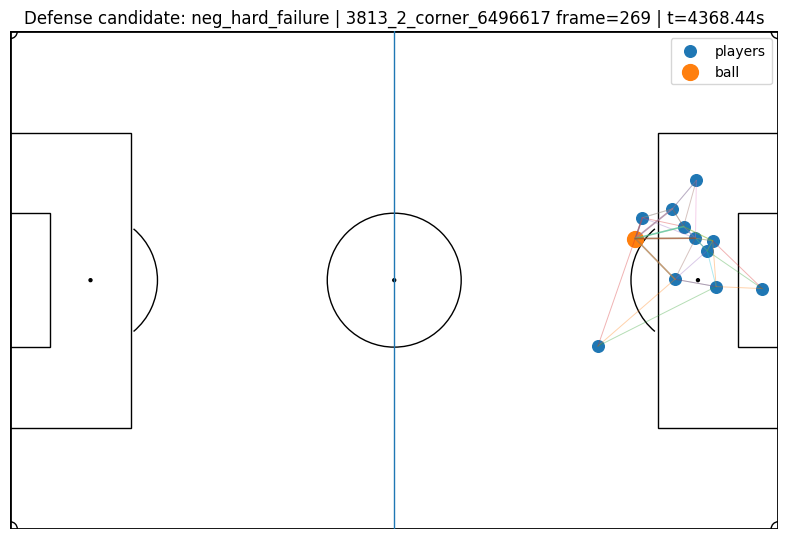

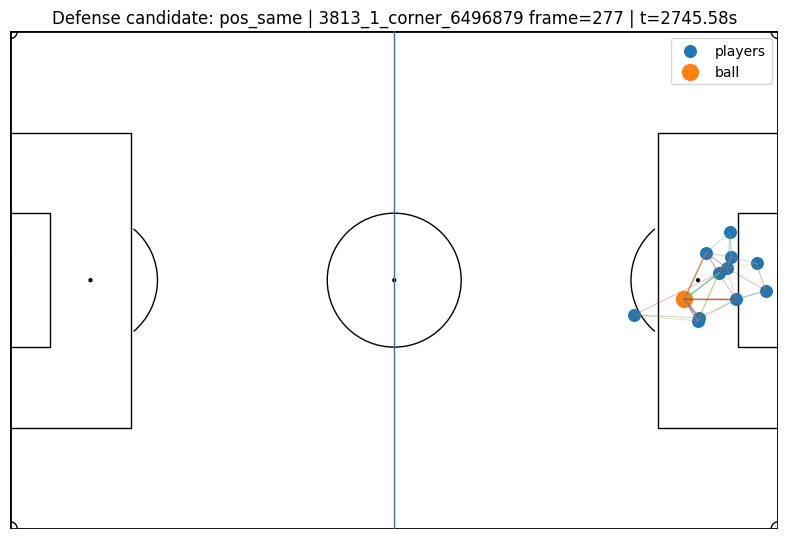

In [33]:
# Optional: plot one retrieved successful defense and one hard negative, if their NPZ files exist.
if pairs is not None and 'selected_pairs' in globals() and not selected_pairs.empty:
    for pair_type in ["pos_retrieved_success", "neg_hard_failure", "pos_same"]:
        rows = selected_pairs[selected_pairs["pair_type"] == pair_type].sort_values("weight", ascending=False)
        if rows.empty:
            continue
        defense_id = rows.iloc[0]["defense_id"]
        if defense_id not in ep_lookup.index:
            continue
        drow = ep_lookup.loc[defense_id]
        if "npz_defense" not in drow.index or pd.isna(drow["npz_defense"]):
            continue
        try:
            dz, dp = load_npz(drow["npz_defense"])
            if "Xseq" in dz.files:
                t = dz["Xseq"].shape[0] // 2
                plot_frame(dz, t, title=f"Defense candidate: {pair_type} | {defense_id}", out_path=FIG_DIR / f"defense_candidate_{pair_type}.png")
        except Exception as e:
            print("Could not plot defense candidate", pair_type, defense_id, e)

## 10. Paper/GitHub-ready exports

This cell writes compact tables that can be copied into the paper or README.

In [34]:
# Label by split table.
if {"split", "coarse_label"}.issubset(episodes.columns):
    coarse_by_split = pd.crosstab(episodes["split"], episodes["coarse_label"])
    coarse_by_split.loc["Total"] = coarse_by_split.sum(axis=0)
    display(coarse_by_split)
    coarse_by_split.to_csv(TABLE_DIR / "coarse_labels_by_split.csv")

# Anchor by split table.
if {"split", "anchor_type"}.issubset(episodes.columns):
    anchor_by_split = pd.crosstab(episodes["split"], episodes["anchor_type"])
    anchor_by_split.loc["Total"] = anchor_by_split.sum(axis=0)
    display(anchor_by_split)
    anchor_by_split.to_csv(TABLE_DIR / "anchor_types_by_split.csv")

# Pair type counts.
if pairs is not None and "pair_type" in pairs.columns:
    pair_counts = safe_value_counts(pairs["pair_type"].astype(str))
    display(pair_counts)
    pair_counts.to_csv(TABLE_DIR / "pair_type_counts.csv", index=False)

print("Saved exploration outputs to:", OUT_DIR)

coarse_label,FOUL_STOP,STOPPED_BY_DEFENSE,SUCCESS,UNKNOWN
split,,,,
test,125,234,27,60
train,852,1795,285,362
val,89,172,27,42
Total,1066,2201,339,464


anchor_type,corner,foul_explicit,free_kick,goal,penalty,shot
split,,,,,,
test,54,109,213,8,4,58
train,455,712,1443,104,19,561
val,56,76,136,10,1,51
Total,565,897,1792,122,24,670


,pair_type,count
0,neg_hard_failure,12210
1,pos_retrieved_success,9990
2,pos_same,4070


Saved exploration outputs to: curated_dataset_wc22\_global\exploration_outputs
